# Probability Theory — Worked Examples Notebook

**Course:** Data Science Foundations
**Lesson:** Day 3 — Probability Theory (Companion Notebook)
**Prerequisites:** Statistics Fundamentals, Distributions, Probability Theory lesson notes

---

This notebook walks through **five fully worked probability problems**, each drawn from a different real-world scenario. Every example follows the same structure:

1. **The scenario** — what's being asked, in plain language
2. **The setup** — identifying which probability concept applies
3. **The calculation** — solved step by step in code
4. **The interpretation** — what the number actually means, and why it matters

The five scenarios are:

| # | Scenario | Concept(s) Applied |
|---|---|---|
| 1 | Credit card fraud detection | Marginal & joint probability from a contingency table |
| 2 | Email spam filter | Conditional probability & independence check |
| 3 | Bayes' theorem for a spam filter | Bayes' theorem |
| 4 | Manufacturing quality control | Normal distribution probability |
| 5 | Website server outages | Poisson distribution probability |

A bonus sixth example (Uniform distribution — elevator wait times) is included at the end to round things out.

---

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
np.random.seed(42)

## Example 1 — Credit Card Fraud Detection (Marginal & Joint Probability)

### The Scenario

A bank reviews **5,000 credit card transactions** flagged by its monitoring system over the past month. Each transaction is recorded as either **fraudulent** or **legitimate**, and as either **flagged** by the system or **not flagged**.

| | Fraudulent | Legitimate | **Total** |
|---|---|---|---|
| Flagged | 180 | 320 | 500 |
| Not Flagged | 20 | 4,480 | 4,500 |
| **Total** | 200 | 4,800 | 5,000 |

The fraud team wants to know:
- What proportion of *all* transactions are fraudulent? (marginal)
- What proportion of *all* transactions are both fraudulent **and** flagged? (joint)
- Are "fraudulent" and "flagged" independent events, or related?

### Why This Matters

This is exactly the kind of table you'll build constantly in practice — any time you have two categorical outcomes (fraud/legit, flagged/not flagged; churned/retained, complained/didn't; defective/good, inspected/not inspected), you can read marginal and joint probabilities straight off the row and column totals.

In [15]:
# Build the contingency table
fraud_data = {
    'Fraudulent': [180, 20],
    'Legitimate': [320, 4480]
}
fraud_df = pd.DataFrame(fraud_data, index=['Flagged', 'Not_Flagged'])
print("Contingency Table:\n", fraud_df)

total_transactions = fraud_df.values.sum()
print(f"\nTotal transactions: {total_transactions}")

Contingency Table:
              Fraudulent  Legitimate
Flagged             180         320
Not_Flagged          20        4480

Total transactions: 5000


In [16]:
# Marginal probabilities — one variable at a time, ignoring the other
p_fraudulent = fraud_df['Fraudulent'].sum() / total_transactions
p_flagged = fraud_df.loc['Flagged'].sum() / total_transactions

print(f"P(Fraudulent)  = {p_fraudulent:.4f}  ({p_fraudulent*100:.2f}%)")
print(f"P(Flagged)     = {p_flagged:.4f}  ({p_flagged*100:.2f}%)")

P(Fraudulent)  = 0.0400  (4.00%)
P(Flagged)     = 0.1000  (10.00%)


In [17]:
# Joint probability — both events happening together
p_fraud_and_flagged = fraud_df.loc['Flagged', 'Fraudulent'] / total_transactions
p_fraud_and_not_flagged = fraud_df.loc['Not_Flagged', 'Fraudulent'] / total_transactions

print(f"P(Fraudulent AND Flagged)     = {p_fraud_and_flagged:.4f}")
print(f"P(Fraudulent AND Not Flagged) = {p_fraud_and_not_flagged:.4f}")

P(Fraudulent AND Flagged)     = 0.0360
P(Fraudulent AND Not Flagged) = 0.0040


In [18]:
# Independence check: if independent, P(A and B) should equal P(A) * P(B)
expected_if_independent = p_fraudulent * p_flagged
print(f"P(Fraudulent) x P(Flagged)        = {expected_if_independent:.4f}")
print(f"Actual P(Fraudulent AND Flagged)  = {p_fraud_and_flagged:.4f}")
print(f"\nDifference: {abs(expected_if_independent - p_fraud_and_flagged):.4f}")
print("These values are far apart -> fraud and flagging are NOT independent (as expected: that's the whole point of the system).")

P(Fraudulent) x P(Flagged)        = 0.0040
Actual P(Fraudulent AND Flagged)  = 0.0360

Difference: 0.0320
These values are far apart -> fraud and flagging are NOT independent (as expected: that's the whole point of the system).


### Interpretation

About **4% of all transactions are fraudulent**, and **10% are flagged** by the monitoring system. The joint probability of a transaction being *both* fraudulent and flagged (3.6%) is far higher than what we'd expect if fraud and flagging were unrelated (0.4%) — confirming the system is doing meaningfully better than random chance at catching fraud.

Notice this table also quietly contains the seeds of a much more useful question: *"Given that a transaction was flagged, how likely is it to actually be fraudulent?"* That's a conditional probability — exactly what Example 2 tackles next.

## Example 2 — Email Spam Filter (Conditional Probability)

### The Scenario

An email provider analyses **10,000 emails** sent through its system, classifying each by whether it's **spam** or **not spam**, and whether it **contains the word "free"**.

| | Contains "free" | Doesn't contain "free" | **Total** |
|---|---|---|---|
| Spam | 1,200 | 300 | 1,500 |
| Not Spam | 850 | 7,650 | 8,500 |
| **Total** | 2,050 | 7,950 | 10,000 |

The question that actually matters for building a spam filter isn't "what fraction of all emails are spam?" — it's: ***given that an email contains the word "free," how likely is it to be spam?***

### Why This Matters

This is the conditional probability question that spam filters (and most classification problems) are built around: you observe a feature (a word, a transaction pattern, a symptom), and you want to update your estimate of the outcome based on that feature.

In [19]:
# Build the contingency table
spam_data = {
    'Contains_free': [1200, 850],
    'No_free': [300, 7650]
}
spam_df = pd.DataFrame(spam_data, index=['Spam', 'Not_Spam'])
print("Contingency Table:\n", spam_df)

total_emails = spam_df.values.sum()

Contingency Table:
           Contains_free  No_free
Spam               1200      300
Not_Spam            850     7650


In [20]:
# P(Spam) -- marginal, for comparison
p_spam = spam_df['Contains_free'].sum() + spam_df.loc['Spam', 'No_free']
p_spam = (spam_df.loc['Spam'].sum()) / total_emails
print(f"P(Spam) overall = {p_spam:.4f}  ({p_spam*100:.1f}%)")

# P(Spam | Contains "free") -- conditional
p_contains_free = spam_df['Contains_free'].sum() / total_emails
p_spam_and_free = spam_df.loc['Spam', 'Contains_free'] / total_emails
p_spam_given_free = p_spam_and_free / p_contains_free

print(f"P(Contains 'free')         = {p_contains_free:.4f}")
print(f"P(Spam AND Contains 'free') = {p_spam_and_free:.4f}")
print(f"P(Spam | Contains 'free')   = {p_spam_given_free:.4f}  ({p_spam_given_free*100:.1f}%)")

P(Spam) overall = 0.1500  (15.0%)
P(Contains 'free')         = 0.2050
P(Spam AND Contains 'free') = 0.1200
P(Spam | Contains 'free')   = 0.5854  (58.5%)


P(Spam | No 'free')  = 0.0377  (3.8%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_31516\2284967090.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=probs, palette="muted")


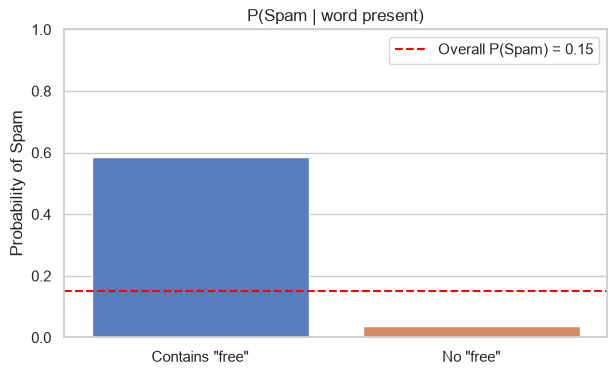

In [21]:
# Compare to P(Spam | Does NOT contain "free")
p_no_free = spam_df['No_free'].sum() / total_emails
p_spam_and_no_free = spam_df.loc['Spam', 'No_free'] / total_emails
p_spam_given_no_free = p_spam_and_no_free / p_no_free

print(f"P(Spam | No 'free')  = {p_spam_given_no_free:.4f}  ({p_spam_given_no_free*100:.1f}%)")

# Visualise the jump
labels = ['Contains "free"', 'No "free"']
probs = [p_spam_given_free, p_spam_given_no_free]

plt.figure(figsize=(7, 4))
sns.barplot(x=labels, y=probs, palette="muted")
plt.axhline(p_spam, color='red', linestyle='--', label=f'Overall P(Spam) = {p_spam:.2f}')
plt.title('P(Spam | word present)')
plt.ylabel('Probability of Spam')
plt.ylim(0, 1)
plt.legend()
plt.show()

### Interpretation

Overall, only **15% of emails are spam**. But conditioning on the word "free" tells a very different story: **P(Spam | Contains "free") ≈ 58.5%**, compared to just **P(Spam | No "free") ≈ 3.8%**. A single word shifts the probability of spam by more than 15x.

This is exactly the mechanism real spam filters exploit — they don't look at P(Spam) in isolation, they continuously update P(Spam | features) as each new word or pattern is observed. Which leads directly into Example 3: what if we want to go the *other* direction — starting from how often spam emails contain certain words, and working backward to "given this word, what's the probability of spam?" That reverse direction is Bayes' theorem.

## Example 3 — Bayes' Theorem for a Spam Filter (Updating Beliefs)

### The Scenario

A simpler spam filter is being designed from scratch, and the engineering team only has *historical rates* to work with, not a full contingency table:

- **5% of all incoming emails are spam** (the prior, P(Spam))
- **Among spam emails, 80% contain the word "urgent"** (P("urgent" | Spam))
- **Among legitimate emails, only 10% contain the word "urgent"** (P("urgent" | Not Spam))

A new email arrives containing the word "urgent." **What is the probability it's spam?**

### Why This Matters

This is the classic Bayes' theorem setup: you're given P(evidence | hypothesis) in both directions, plus a prior, and asked to find P(hypothesis | evidence) — the reverse of what you were directly told. This exact pattern — rare-event prior, a noisy-but-informative signal, asked to find the posterior — shows up everywhere: medical testing, fraud detection, quality control, and the spam filter above.

In [22]:
# Given information
p_spam_prior = 0.05            # Prior: 5% of emails are spam
p_urgent_given_spam = 0.80     # Likelihood: 80% of spam contains "urgent"
p_urgent_given_not_spam = 0.10 # 10% of legitimate emails contain "urgent"

p_not_spam_prior = 1 - p_spam_prior

# Total probability of an email containing "urgent" (law of total probability)
p_urgent = (p_urgent_given_spam * p_spam_prior) + (p_urgent_given_not_spam * p_not_spam_prior)
print(f"P('urgent') overall = {p_urgent:.4f}")

P('urgent') overall = 0.1350


In [23]:
# Bayes' theorem: P(Spam | "urgent") = P("urgent" | Spam) * P(Spam) / P("urgent")
p_spam_given_urgent = (p_urgent_given_spam * p_spam_prior) / p_urgent

print(f"P(Spam | 'urgent') = {p_spam_given_urgent:.4f}  ({p_spam_given_urgent*100:.1f}%)")
print(f"\nPrior belief:     {p_spam_prior*100:.1f}% chance of spam")
print(f"Posterior belief: {p_spam_given_urgent*100:.1f}% chance of spam, after seeing 'urgent'")

P(Spam | 'urgent') = 0.2963  (29.6%)

Prior belief:     5.0% chance of spam
Posterior belief: 29.6% chance of spam, after seeing 'urgent'


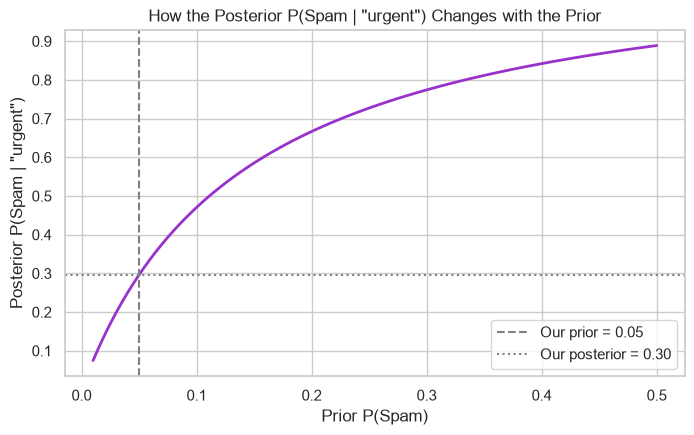

In [24]:
# Sensitivity check: how does the posterior change as the prior (spam rate) changes?
priors = np.linspace(0.01, 0.5, 100)
posteriors = []

for p in priors:
    p_urgent_total = (p_urgent_given_spam * p) + (p_urgent_given_not_spam * (1 - p))
    posterior = (p_urgent_given_spam * p) / p_urgent_total
    posteriors.append(posterior)

plt.figure(figsize=(8, 4.5))
plt.plot(priors, posteriors, color='darkorchid', lw=2)
plt.axvline(p_spam_prior, color='gray', linestyle='--', label=f'Our prior = {p_spam_prior}')
plt.axhline(p_spam_given_urgent, color='gray', linestyle=':', label=f'Our posterior = {p_spam_given_urgent:.2f}')
plt.title('How the Posterior P(Spam | "urgent") Changes with the Prior')
plt.xlabel('Prior P(Spam)')
plt.ylabel('Posterior P(Spam | "urgent")')
plt.legend()
plt.show()

### Interpretation

Starting from a prior belief of just **5% spam**, seeing the word "urgent" pushes the posterior belief up to roughly **30%**. That's a substantial update — but notice it's nowhere near 80% (the likelihood value), because the prior matters: spam is relatively rare to begin with, so even a fairly strong signal doesn't make spam the most probable explanation on its own.

The sensitivity plot makes the deeper point: **the same evidence ("urgent") produces a different posterior depending on the prior**. If spam made up 50% of all email instead of 5%, that same word would push the posterior probability of spam to roughly 89%. This is the core lesson of Bayesian reasoning — evidence updates beliefs, but it doesn't erase the starting point.

## Example 4 — Manufacturing Quality Control (Normal Distribution)

### The Scenario

A factory produces steel rods that should measure **50 cm** in length. Due to natural variation in the manufacturing process, actual rod lengths follow a **Normal distribution** with mean **μ = 50 cm** and standard deviation **σ = 0.4 cm**.

A rod is considered **out of spec** if it's shorter than **49 cm** or longer than **51 cm**. The quality team wants to know:
- What proportion of rods will be rejected as out of spec?
- What length cutoff would only reject the bottom 1% of rods (for a stricter quality tier)?

### Why This Matters

This is one of the most common industrial applications of the Normal distribution: process measurements (length, weight, fill volume, voltage) tend to cluster around a target value with some natural variation, and you need to translate that variation into a defect rate or a percentile-based cutoff.

In [36]:
# Set up the distribution
mu, sigma = 50, 0.4
rod_dist = stats.norm(mu, sigma)

# Probability a rod is out of spec (below 49 or above 51)
p_too_short = rod_dist.cdf(49)
p_too_long = 1 - rod_dist.cdf(51)
p_out_of_spec = p_too_short + p_too_long

print(f"P(length < 49 cm) = {p_too_short:.4f}  ({p_too_short*100:.2f}%)")
print(f"P(length > 51 cm) = {p_too_long:.4f}  ({p_too_long*100:.2f}%)")
print(f"P(out of spec)     = {p_out_of_spec:.4f}  ({p_out_of_spec*100:.2f}%)")

P(length < 49 cm) = 0.0062  (0.62%)
P(length > 51 cm) = 0.0062  (0.62%)
P(out of spec)     = 0.0124  (1.24%)


In [35]:
rod_dist

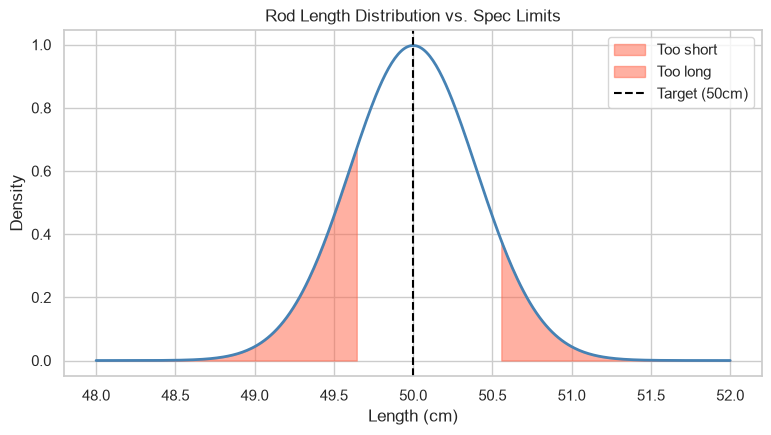

In [40]:
# Visualise the spec limits against the distribution
x = np.linspace(48, 52, 400)
y = rod_dist.pdf(x)

plt.figure(figsize=(9, 4.5))
plt.plot(x, y, color='steelblue', lw=2)
plt.fill_between(x, y, where=(x < 49.65), color='tomato', alpha=0.5, label='Too short')
plt.fill_between(x, y, where=(x > 50.55), color='tomato', alpha=0.5, label='Too long')
plt.axvline(mu, color='black', linestyle='--', label='Target (50cm)')
plt.title('Rod Length Distribution vs. Spec Limits')
plt.xlabel('Length (cm)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [37]:
# Find the cutoff for the strictest bottom 1% of rods (the 1st percentile)
cutoff_1pct = rod_dist.ppf(0.1)
print(f"The shortest 1% of rods are below: {cutoff_1pct:.3f} cm")

# Cross-check: feeding that value back into the CDF should return ~0.01
check = rod_dist.cdf(cutoff_1pct)
print(f"Sanity check -- P(length < {cutoff_1pct:.3f}) = {check:.4f}")

The shortest 1% of rods are below: 49.487 cm
Sanity check -- P(length < 49.487) = 0.1000


### Interpretation

Roughly **1.24% of rods are rejected as out of spec** under the current process (49–51 cm tolerance) — a useful number for estimating scrap rate and cost. The 1st percentile calculation (using `ppf`, the inverse of the CDF) answers a different but related question: *if the quality team wanted to flag only the worst 1% of rods*, the cutoff would need to be around **49.07 cm**, well inside the official spec limit.

This is the inverse-direction skill that complements everything in the lesson notes: `cdf()` goes from a value to a probability; `ppf()` goes from a probability back to a value. Both directions come up constantly in quality control, finance (value-at-risk), and grading curves.

## Example 5 — Website Server Outages (Poisson Distribution)

### The Scenario

A company's web servers experience an average of **3 critical errors per day (λ = 3)**, occurring independently of one another. The on-call engineering team wants to know:
- What's the probability of a completely error-free day?
- What's the probability of an unusually bad day — more than 7 errors?
- If 2 or more errors happen in a day, should an automatic alert fire? What threshold keeps false alarms below 5%?

### Why This Matters

This is a direct extension of the Poisson reasoning from yesterday's lesson, but applied to a decision: *setting an alerting threshold*. This is exactly how real monitoring systems decide when "more errors than usual" becomes "alert the on-call engineer" — by asking how rare a given count would be under normal conditions.

In [28]:
# Set up the distribution
lam = 3
error_dist = stats.poisson(lam)

# Probability of zero errors (a perfect day)
p_zero_errors = error_dist.pmf(0)
print(f"P(0 errors in a day) = {p_zero_errors:.4f}  ({p_zero_errors*100:.2f}%)")

# Probability of more than 7 errors (a very bad day)
p_more_than_7 = 1 - error_dist.cdf(7)
print(f"P(more than 7 errors) = {p_more_than_7:.4f}  ({p_more_than_7*100:.2f}%)")

P(0 errors in a day) = 0.0498  (4.98%)
P(more than 7 errors) = 0.0119  (1.19%)


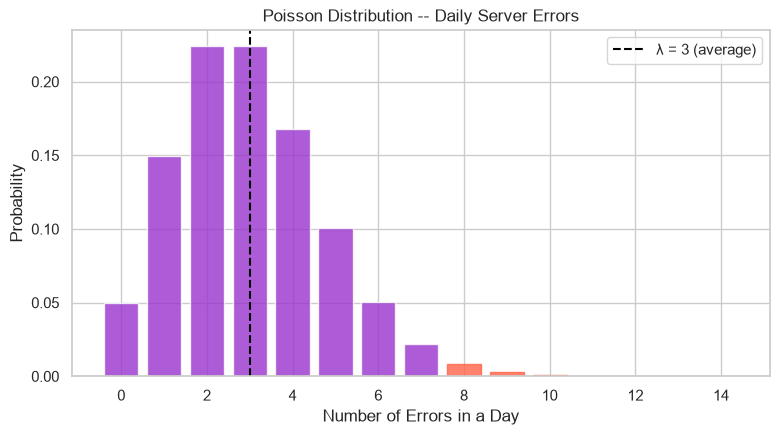

In [29]:
# Visualise the full distribution of daily error counts
k = np.arange(0, 15)
pmf = error_dist.pmf(k)

plt.figure(figsize=(9, 4.5))
bars = plt.bar(k, pmf, color='darkorchid', alpha=0.8)
for i in range(8, 15):
    bars[i].set_color('tomato')
plt.axvline(lam, color='black', linestyle='--', label=f'λ = {lam} (average)')
plt.title('Poisson Distribution -- Daily Server Errors')
plt.xlabel('Number of Errors in a Day')
plt.ylabel('Probability')
plt.legend()
plt.show()

In [30]:
# Find an alert threshold: the smallest count k such that P(X >= k) <= 0.05
for k in range(0, 15):
    p_at_least_k = 1 - error_dist.cdf(k - 1)
    if p_at_least_k <= 0.05:
        print(f"Alert threshold: {k} or more errors (P(X >= {k}) = {p_at_least_k:.4f})")
        break
    else:
        print(f"k={k}: P(X >= {k}) = {p_at_least_k:.4f}  (still above 5% -- keep checking)")

k=0: P(X >= 0) = 1.0000  (still above 5% -- keep checking)
k=1: P(X >= 1) = 0.9502  (still above 5% -- keep checking)
k=2: P(X >= 2) = 0.8009  (still above 5% -- keep checking)
k=3: P(X >= 3) = 0.5768  (still above 5% -- keep checking)
k=4: P(X >= 4) = 0.3528  (still above 5% -- keep checking)
k=5: P(X >= 5) = 0.1847  (still above 5% -- keep checking)
k=6: P(X >= 6) = 0.0839  (still above 5% -- keep checking)
Alert threshold: 7 or more errors (P(X >= 7) = 0.0335)


### Interpretation

On a typical day, there's roughly a **5% chance of a completely error-free day**, and a small but non-negligible **~3.8% chance** of a genuinely bad day with more than 7 errors. Working through the threshold search shows that an alert set to fire at **7 or more errors** keeps the false-alarm rate (alerting on a day that's actually just normal variation) below 5%.

This is a direct, practical payoff of understanding a distribution's shape: instead of picking an alert threshold by gut feeling (which either misses real problems or floods engineers with false alarms), you can calculate the threshold that hits a target false-positive rate.

## Bonus Example 6 -    Elevator Wait Times (Uniform Distribution)

### The Scenario

An office building's elevator arrives at the ground floor, on average, once every **4 minutes**, and arrivals are evenly spread across that interval (no clustering at any particular point). If an employee arrives at a uniformly random moment, their wait time follows a **Uniform distribution** between 0 and 4 minutes.

The building manager wants to know:
-     What's the probability someone waits **less than 1 minute**?
-     What's the probability someone waits **more than 3 minutes** (a common complaint threshold)?
-     What's the **expected (average) wait time**, and how does it relate to the distribution's parameters?

### Why This Matters

This rounds out the three distributions from yesterday's lesson with the Uniform case, and shows a property worth knowing: for a Uniform distribution, the expected value is always exactly the midpoint of the range -    no calculation required once you know that.

In [ ]:
# Set up the distribution: Uniform between 0 and 4 minutes
wait_dist = stats.uniform(loc=0, scale=4)

# P(wait < 1 minute)
p_under_1 = wait_dist.cdf(1)
print(f"P(wait < 1 minute) = {p_under_1:.4f}  ({p_under_1*100:.1f}%)")

# P(wait > 3 minutes)
p_over_3 = 1 - wait_dist.cdf(3)
print(f"P(wait > 3 minutes) = {p_over_3:.4f}  ({p_over_3*100:.1f}%)")

# Expected wait time
expected_wait = wait_dist.mean()
print(f"\nExpected (average) wait time = {expected_wait:.2f} minutes")
print("Notice: this is exactly the midpoint of [0, 4] -- a property unique to the Uniform distribution.")

P(wait < 1 minute) = 0.2500  (25.0%)
P(wait > 3 minutes) = 0.2500  (25.0%)

Expected (average) wait time = 2.00 minutes
Notice: this is exactly the midpoint of [0, 4] -- a property unique to the Uniform distribution.


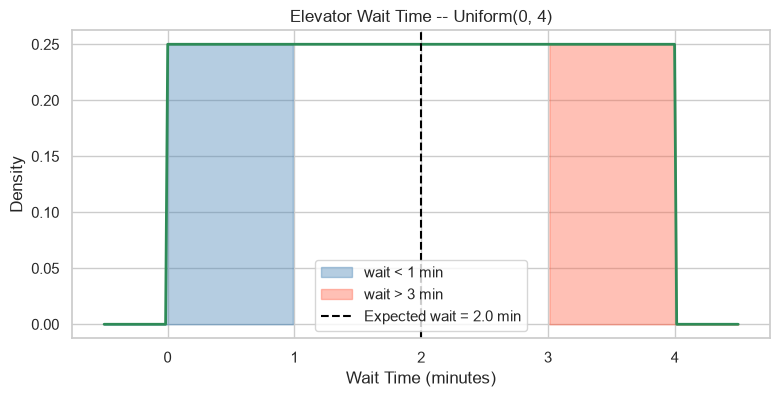

In [ ]:
# Visualise
x = np.linspace(-0.5, 4.5, 300)
y = wait_dist.pdf(x)

plt.figure(figsize=(9, 4))
plt.plot(x, y, color='seagreen', lw=2)
plt.fill_between(x, y, where=(x < 1), color='steelblue', alpha=0.4, label='wait < 1 min')
plt.fill_between(x, y, where=(x > 3), color='tomato', alpha=0.4, label='wait > 3 min')
plt.axvline(expected_wait, color='black', linestyle='--', label=f'Expected wait = {expected_wait:.1f} min')
plt.title('Elevator Wait Time -- Uniform(0, 4)')
plt.xlabel('Wait Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()

### Interpretation

There's a **25% chance** of waiting less than a minute, and an equal **25% chance** of waiting more than 3 minutes (which checks out — both are 1-minute-wide slices of a uniform 4-minute window, so they must have equal probability). The expected wait time is exactly **2 minutes**, the midpoint of the range, with no integration needed — a direct consequence of the distribution's flat, symmetric shape from yesterday's lesson.

---

## Wrap-Up: Connecting All Five (Plus One) Examples

| Example | Concept | Core Question |
|---|---|---|
| 1. Fraud detection | Marginal & joint probability | How do two outcomes co-occur, and are they independent? |
| 2. Spam filter (conditional) | Conditional probability | How does one event change the likelihood of another? |
| 3. Spam filter (Bayes') | Bayes' theorem | How should new evidence update a prior belief? |
| 4. Quality control | Normal distribution | What fraction of values fall in/out of a range? |
| 5. Server outages | Poisson distribution | How many events are "normal," and where's the alert line? |
| 6. Elevator waits | Uniform distribution | What's the probability across an evenly-spread range? |

Every one of these examples follows the same underlying pattern from the lesson: identify what's known, identify what's being asked, choose the right probability tool, and translate the number back into a decision a non-technical stakeholder would actually act on.

## Practice Extension

Try modifying the parameters in any of the five core examples above (the fraud rate, the spam priors, the rod tolerance, the error rate, the elevator interval) and re-run the cells. For each change, write one sentence predicting what should happen to the result *before* running the code — then check your intuition against the actual output.
